In [55]:
import importlib
import auxfun
importlib.reload(auxfun)
from auxfun import *

In [56]:
path = "..\\Envíos\\historico_operativa.xlsx"
fecha_fin = "2026-05-14"
capital_inicial = 10_000_000
universo_tickers = auxfun.get_eurostoxx50_tickers()

hist = historico_valor_cartera(path, fecha_fin, capital_inicial=10_000_000, hoja="Operativa", incluir_costes=True)
hist

c:\Users\Deportivo Estadio\Desktop\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\Trabajo_gestion_cuantitativa\Monitoring\auxfun.py:62: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  fecha_fin = pd.Timestamp.today().normalize() if fecha_fin is None else pd.to_datetime(fecha_fin, dayfirst=True).normalize()


,Cash,Valor acciones,Dividendos diarios,Valor cartera,Rentabilidad diaria
Date,,,,,
2026-03-12,0.000000,9.990013e+06,0.000,9.990013e+06,0.000000
2026-03-13,0.000000,9.908388e+06,0.000,9.908388e+06,-0.008171
2026-03-16,0.000000,9.973624e+06,0.000,9.973624e+06,0.006584
2026-03-17,0.000000,1.000886e+07,0.000,1.000886e+07,0.003533
2026-03-18,0.000000,9.867523e+06,0.000,9.867523e+06,-0.014121
2026-03-19,0.000000,9.586114e+06,0.000,9.586114e+06,-0.028519
2026-03-20,-2665.153383,9.447849e+06,0.000,9.445184e+06,-0.014701
2026-03-23,4263.846617,9.521885e+06,6929.000,9.526149e+06,0.008572
2026-03-24,4263.846617,9.492344e+06,0.000,9.496608e+06,-0.003101


In [57]:
res = auxfun.resultados_cartera_bmk(
    archivo=path, universo_tickers=universo_tickers, fecha_fin=fecha_fin,
    capital_inicial=capital_inicial, benchmark="^STOXX50E"
)

series_grafico = res["series"]
semanal = res["semanal"]
detalle_acumulado = res["detalle_acumulado"]
final = res["final"]
semanal_fmt = res["semanal_fmt"]
final_fmt = res["final_fmt"]
tabla_metricas = res["tabla_metricas"]
tabla_metricas_fmt = res["tabla_metricas_fmt"]

display(semanal_fmt)

c:\Users\Deportivo Estadio\Desktop\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\Trabajo_gestion_cuantitativa\Monitoring\auxfun.py:62: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  fecha_fin = pd.Timestamp.today().normalize() if fecha_fin is None else pd.to_datetime(fecha_fin, dayfirst=True).normalize()
c:\Users\Deportivo Estadio\Desktop\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\Trabajo_gestion_cuantitativa\Monitoring\auxfun.py:62: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  fecha_fin = pd.Timestamp.today().normalize() if fecha_fin is None else pd.to_datetime(fecha_fin, dayfirst=True).normalize()


,NAV inicial,NAV final,Rent. cartera neta,Alpha,Ef. selección,Ef. pesos,Costes
Periodo,,,,,,,
2026-03-12 → 2026-03-20,"10,000.0 k€","9,447.2 k€",-5.53%,-1.22%,-0.40%,-0.72%,-0.10%
2026-03-20 → 2026-03-27,"9,447.2 k€","9,410.7 k€",-0.39%,-0.47%,-0.10%,-0.35%,-0.02%
2026-03-27 → 2026-04-07,"9,410.7 k€","9,723.8 k€",3.33%,1.01%,0.27%,0.80%,-0.06%
2026-04-07 → 2026-04-10,"9,723.8 k€","10,137.2 k€",4.25%,-0.95%,0.57%,-1.49%,-0.02%
2026-04-10 → 2026-04-17,"10,137.2 k€","10,159.0 k€",0.21%,-2.01%,-0.26%,-1.72%,-0.02%
2026-04-17 → 2026-04-24,"10,159.0 k€","10,116.9 k€",-0.41%,2.46%,0.49%,2.00%,-0.03%
2026-04-24 → 2026-05-04,"10,116.9 k€","10,159.8 k€",0.42%,2.46%,0.92%,1.58%,-0.04%
2026-05-04 → 2026-05-08,"10,159.8 k€","10,181.5 k€",0.21%,-2.35%,0.07%,-2.39%,-0.03%
2026-05-08 → 2026-05-14,"10,181.5 k€","10,324.8 k€",1.41%,2.26%,0.44%,1.84%,-0.02%


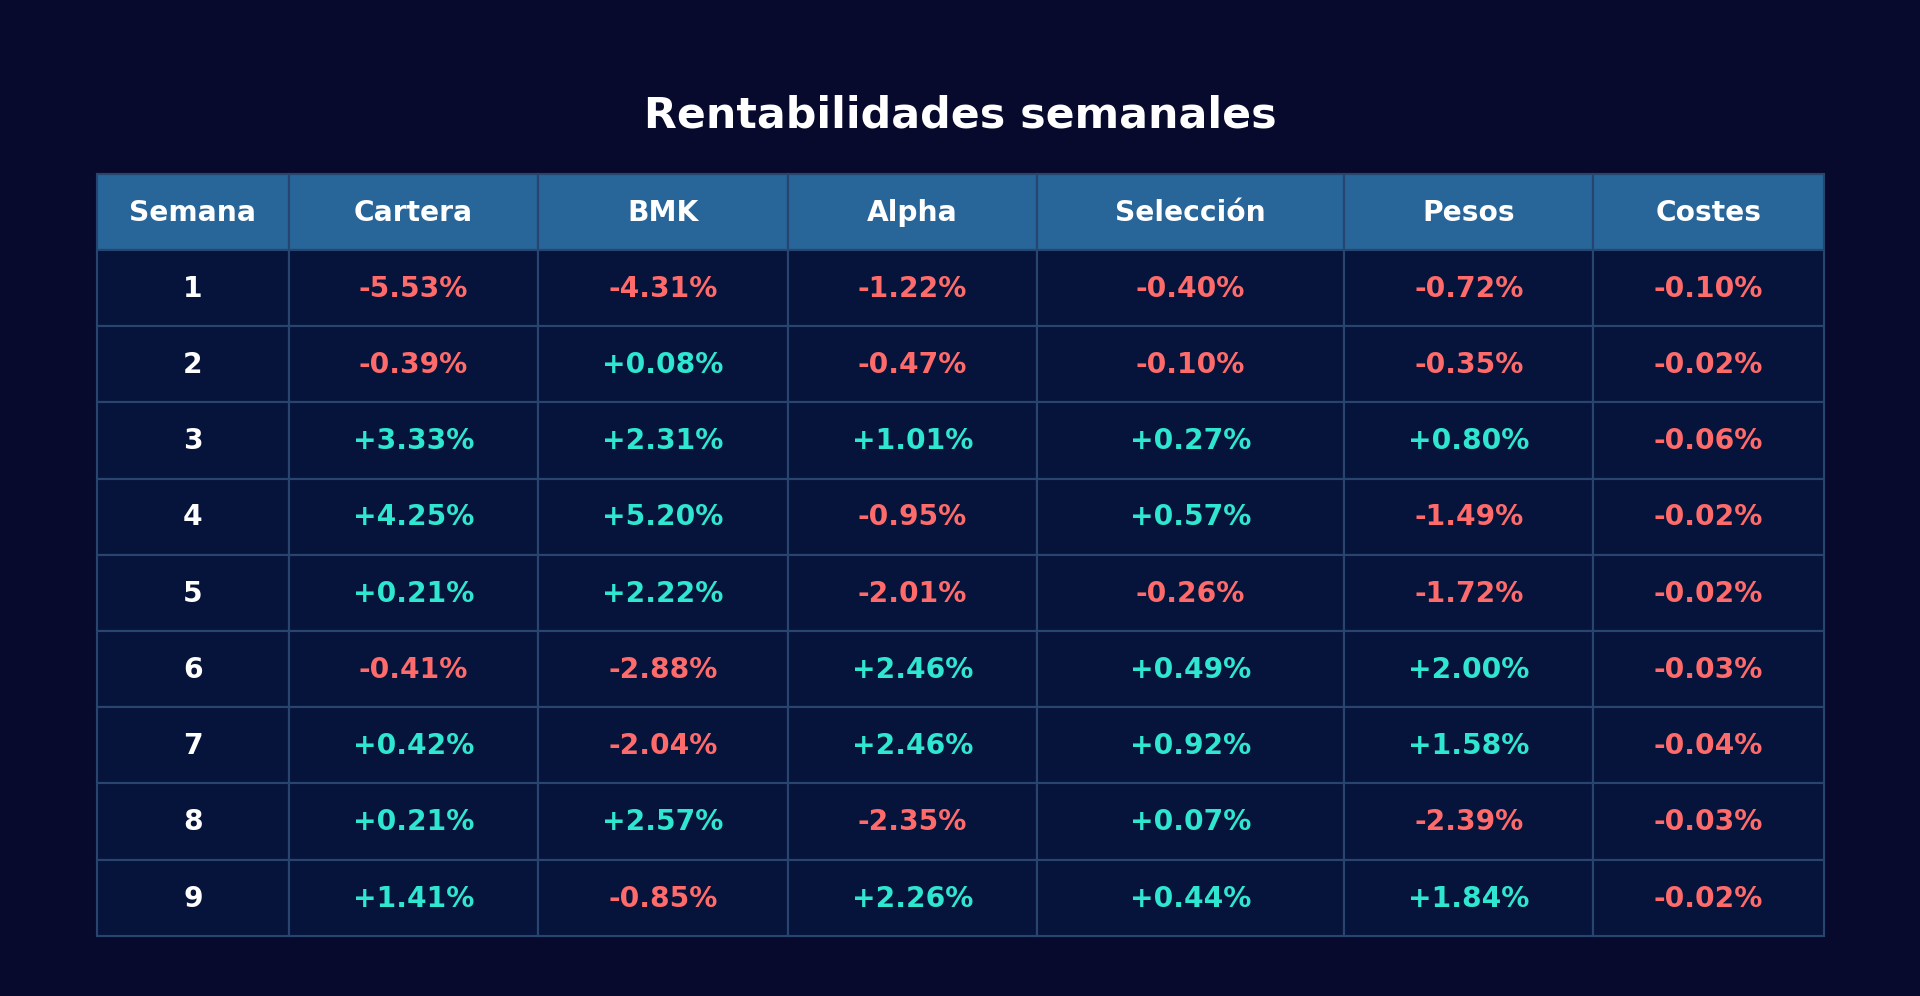

In [58]:
fig, ax = auxfun.tabla_semanal_presentacion(
    semanal,
    ultimas=10
)

c:\Users\Deportivo Estadio\Desktop\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\Trabajo_gestion_cuantitativa\Monitoring\auxfun.py:633: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


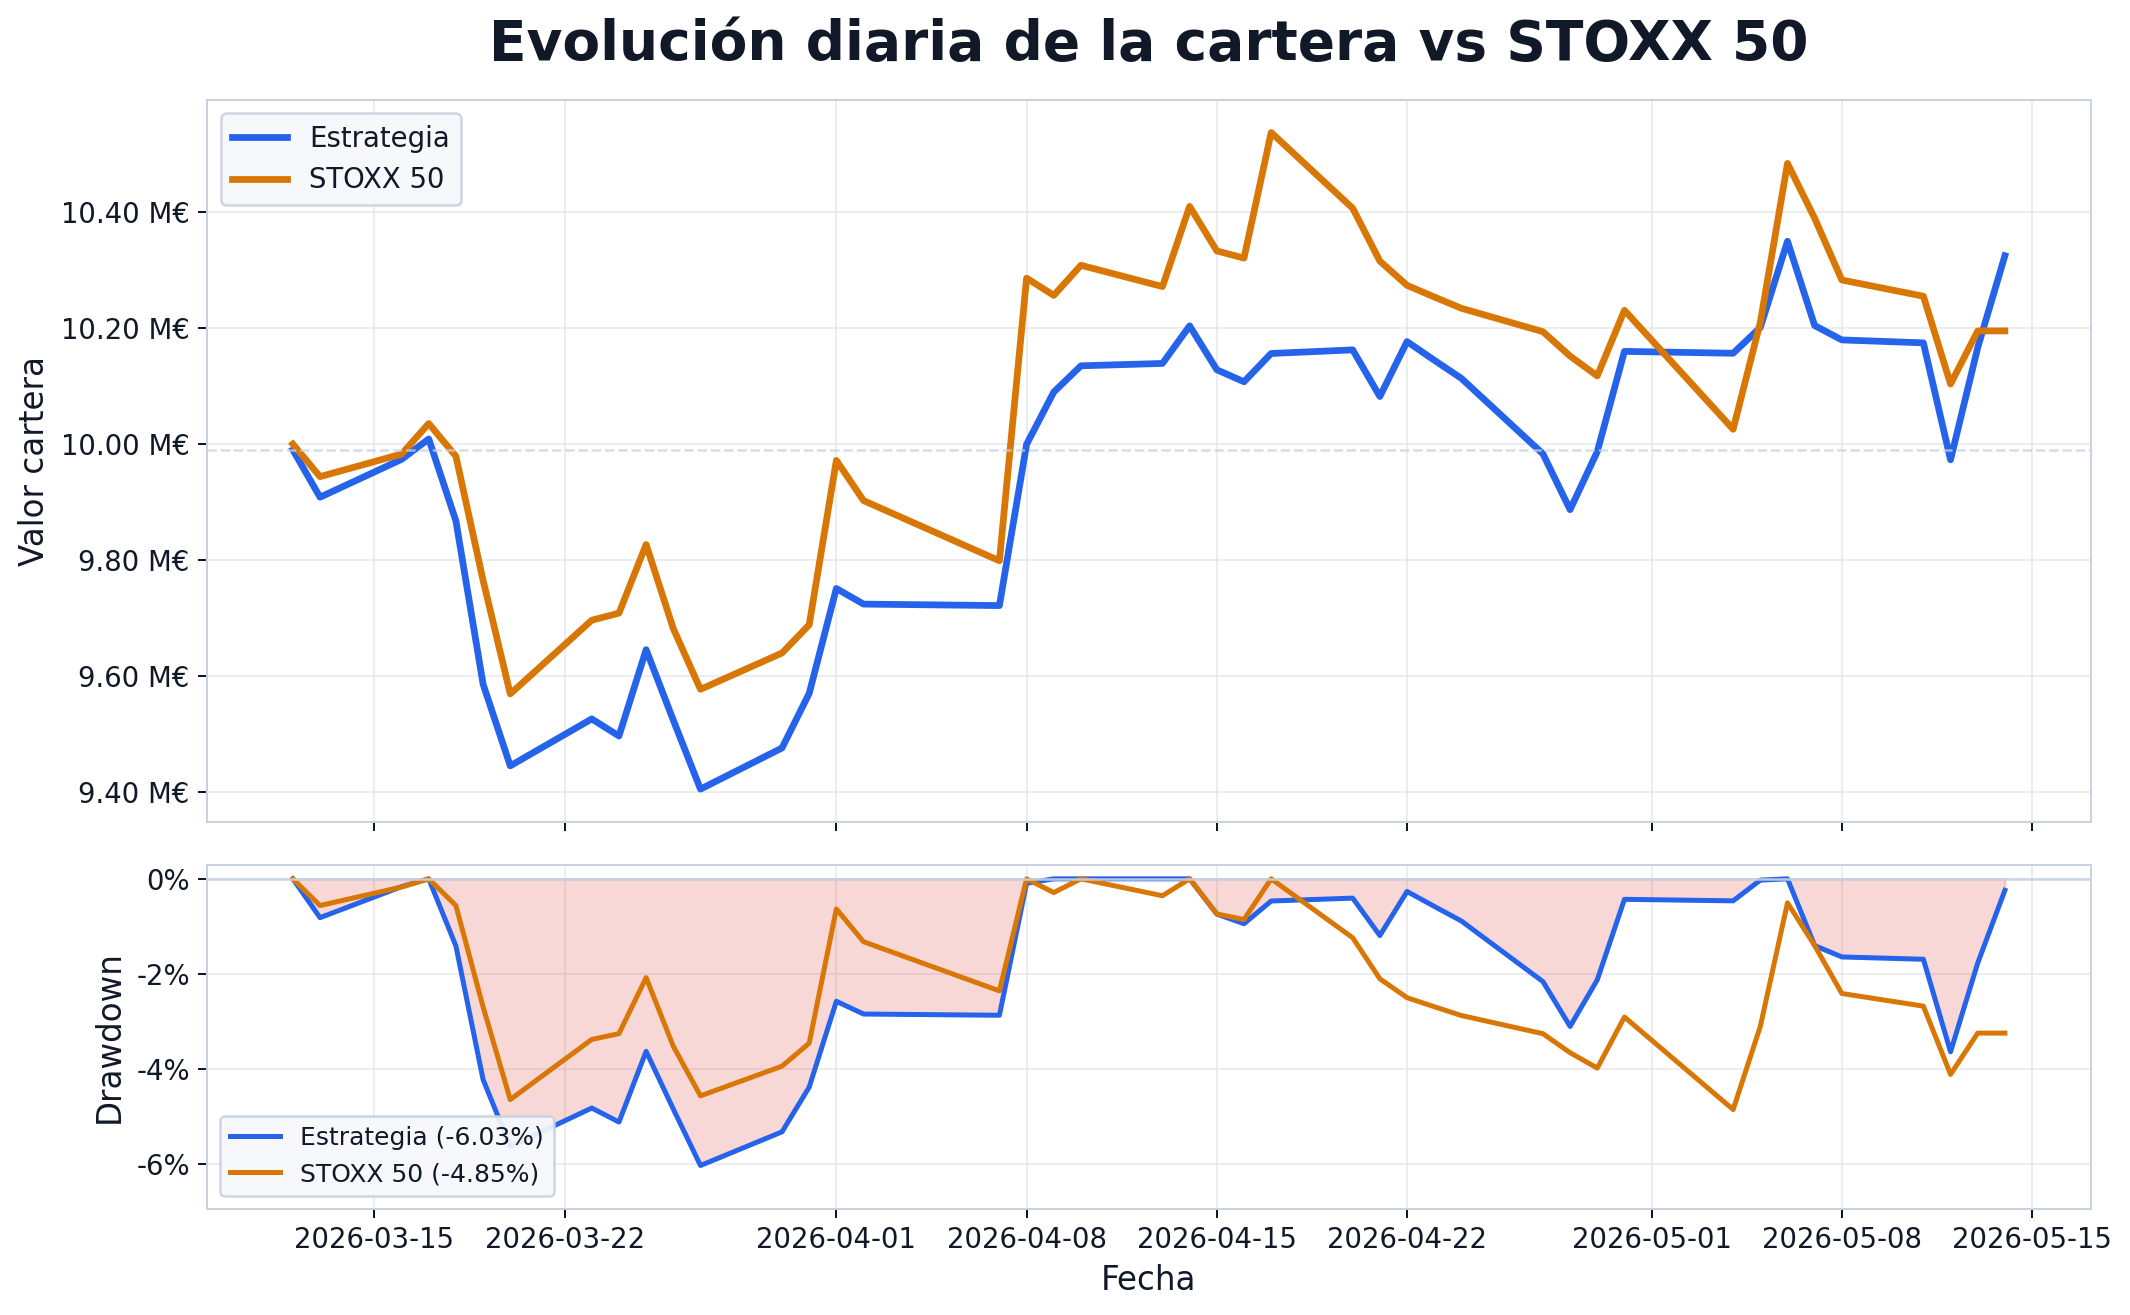

In [59]:
tema = auxfun.TEMA_MEMORIA
# tema = auxfun.TEMA_PRESENTACION
fig, axes = auxfun.grafico_evolucion_drawdown(
    series_grafico,
    titulo="Evolución diaria de la cartera vs STOXX 50",
    tema=tema
)

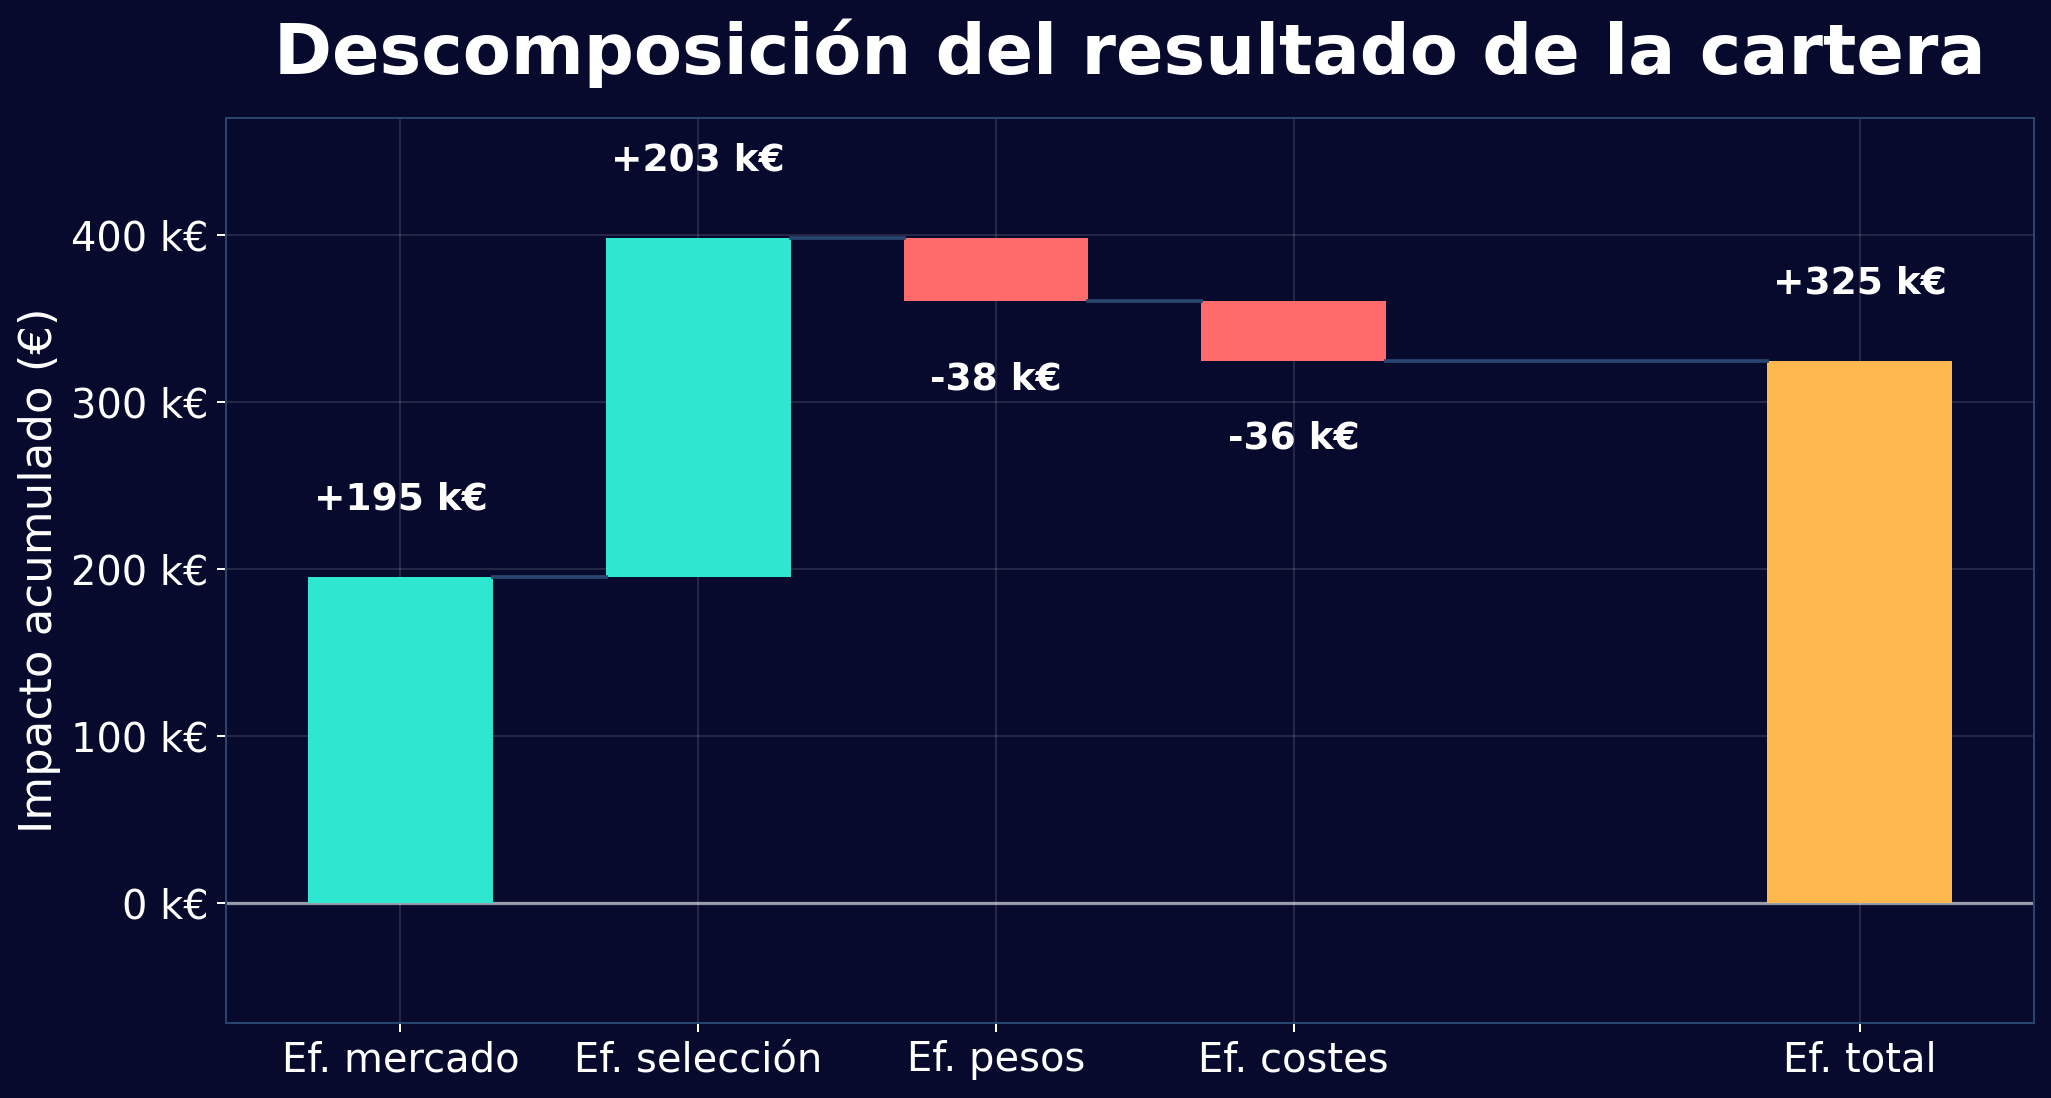

,Impacto (€),Impacto (%)
Efecto mercado,195132.773165,0.019513
Ef. selección,203248.657815,0.020325
Ef. pesos,-37943.217221,-0.003794
Costes,-35684.513158,-0.003568
Resultado total,324753.700601,0.032475


In [65]:
tabla_efectos, fig, ax = grafico_descomposicion_efectos(
    res["final"],
    formato="presentación"
)

display(tabla_efectos)

In [61]:
display(tabla_metricas_fmt)

Estrategia,Rentabilidad,Volatilidad,Max DD,Sharpe
Estrategia,3.25%,18.89%,-6.03%,1.03
STOXX 50,1.95%,22.55%,-4.85%,0.54


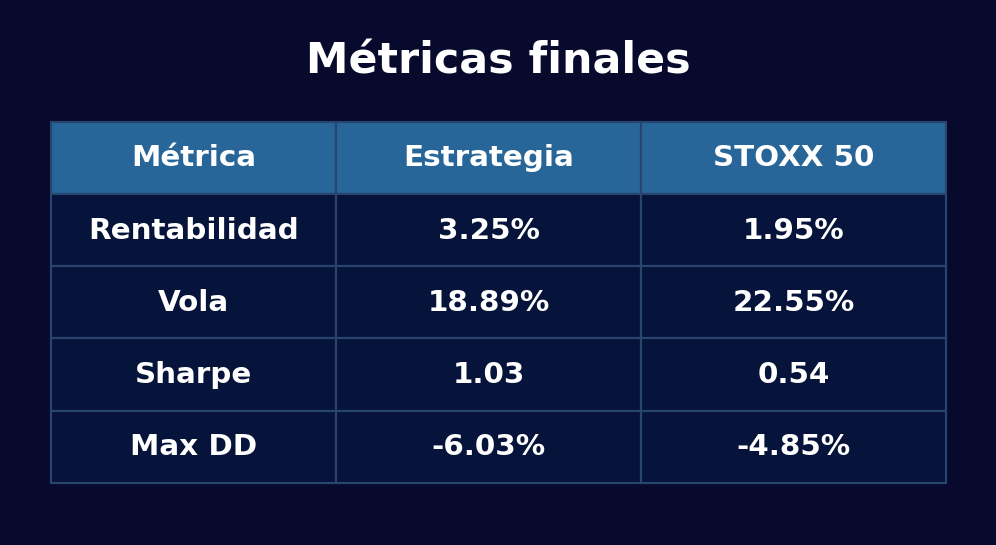

In [62]:
fig, ax = auxfun.tabla_metricas_presentacion(
    tabla_metricas, metricas=("Rentabilidad", "Volatilidad", "Sharpe", "Max DD")
)

c:\Users\Deportivo Estadio\Desktop\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\Trabajo_gestion_cuantitativa\Monitoring\auxfun.py:62: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  fecha_fin = pd.Timestamp.today().normalize() if fecha_fin is None else pd.to_datetime(fecha_fin, dayfirst=True).normalize()


P&L medio por activo: 12,490.25 €


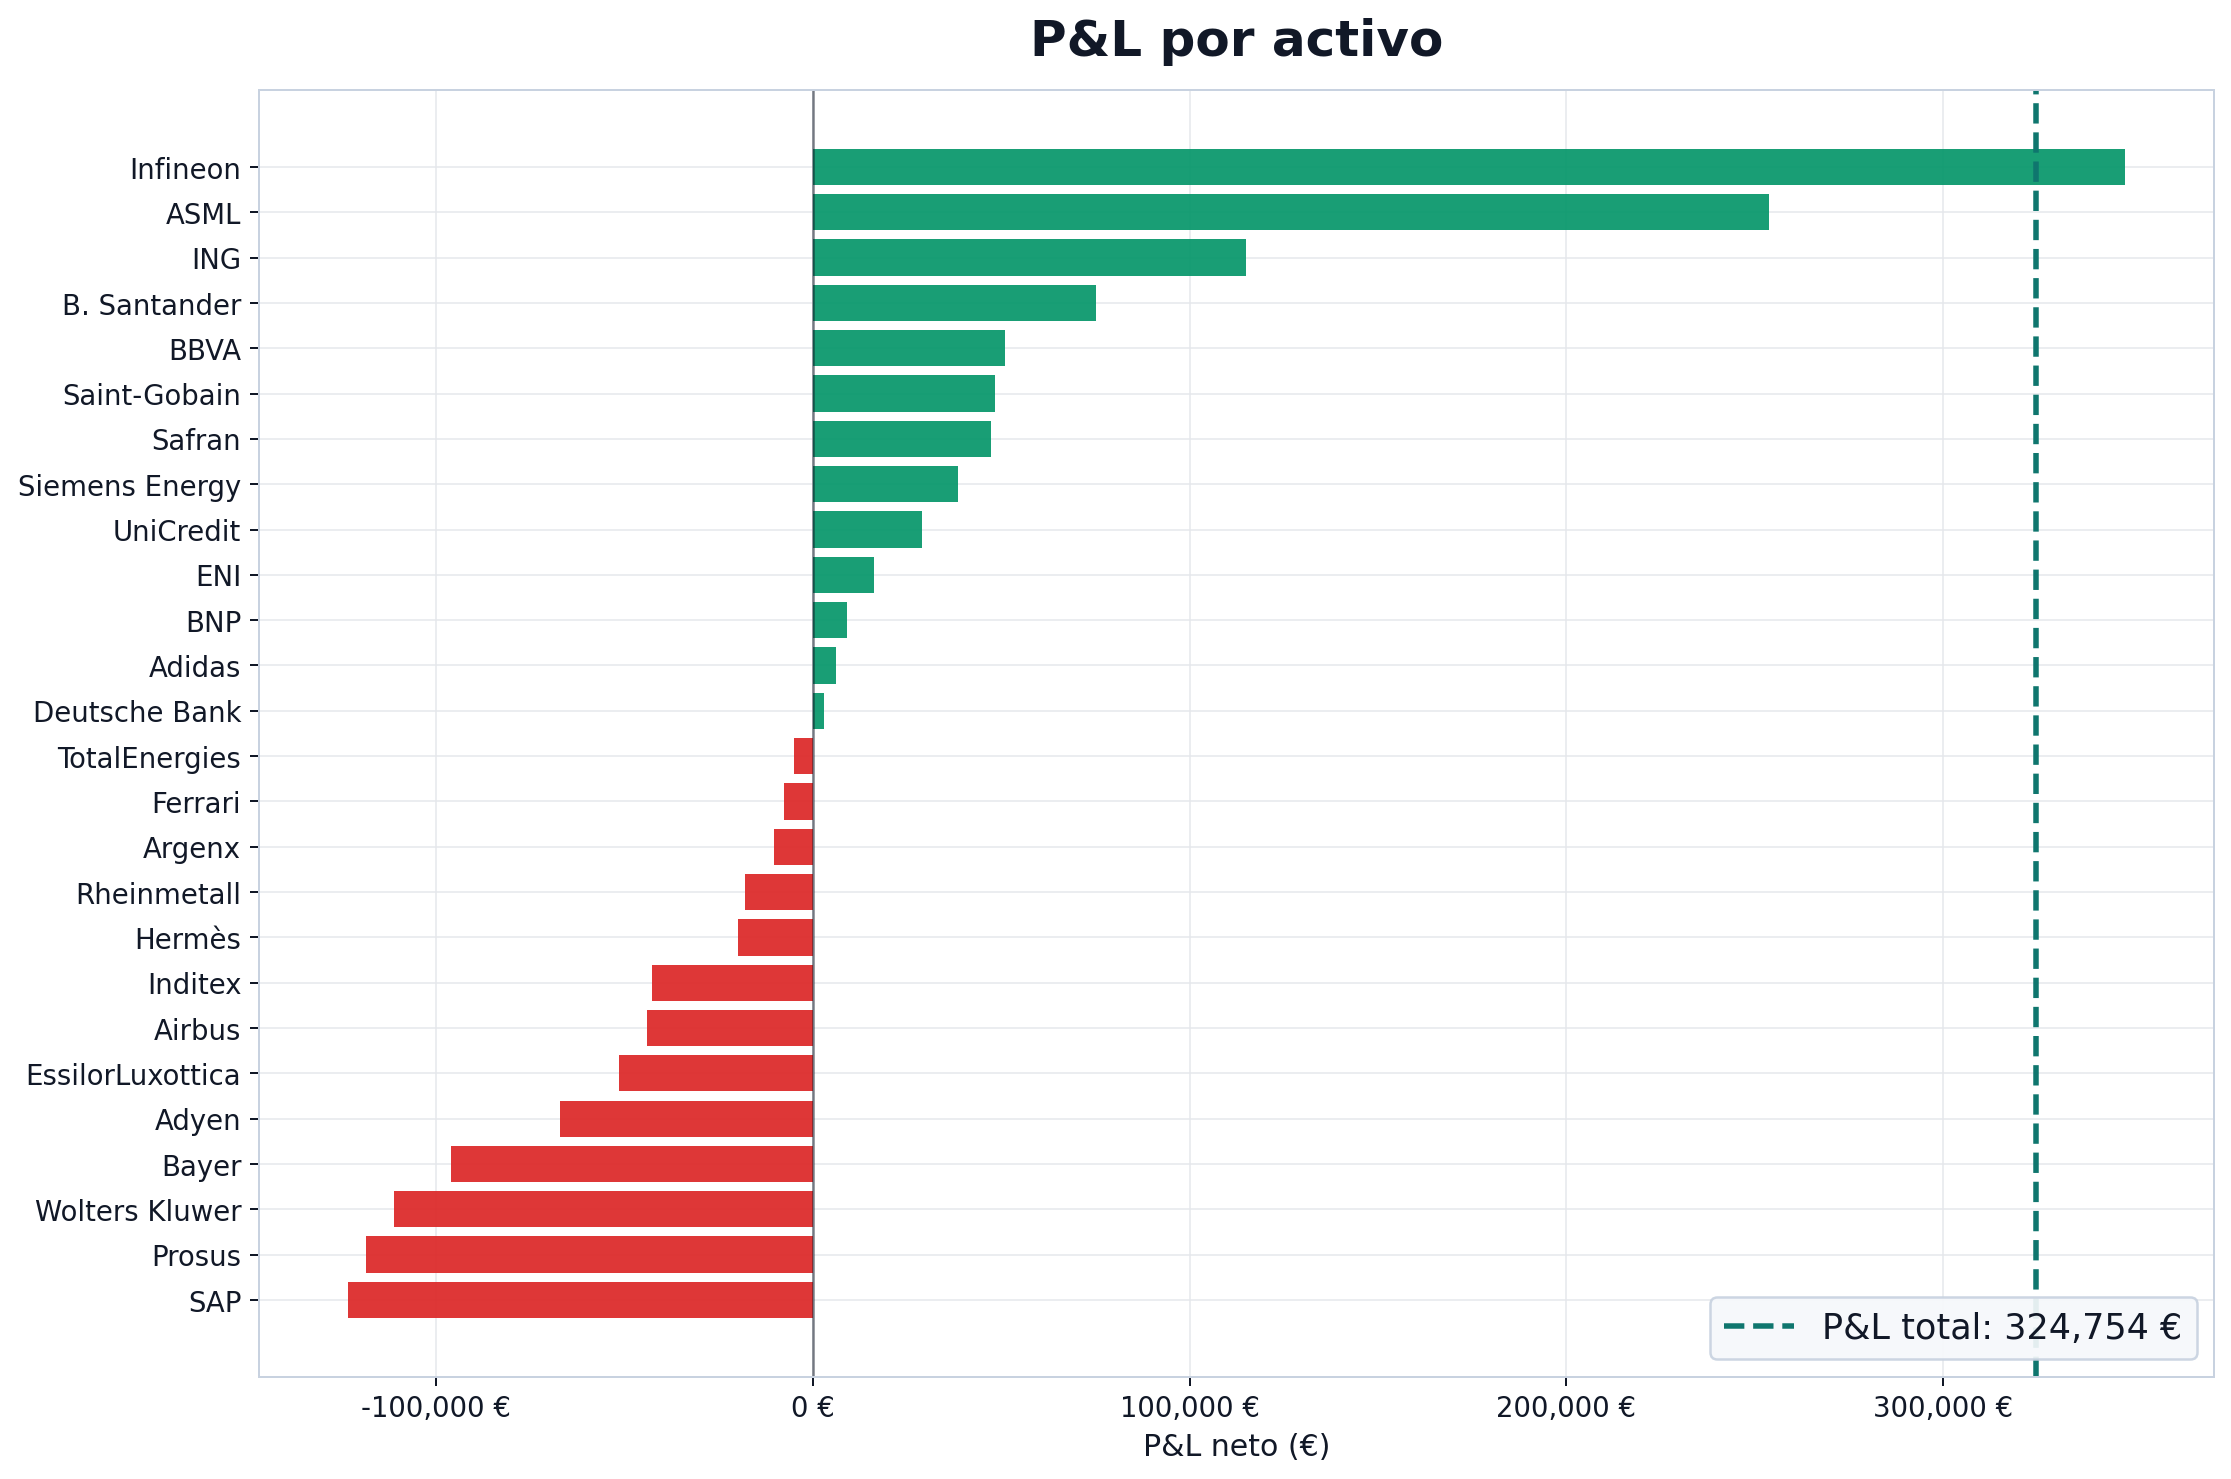

c:\Users\Deportivo Estadio\Desktop\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\Trabajo_gestion_cuantitativa\Monitoring\auxfun.py:62: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  fecha_fin = pd.Timestamp.today().normalize() if fecha_fin is None else pd.to_datetime(fecha_fin, dayfirst=True).normalize()


P&L medio por activo: 12,490.25 €


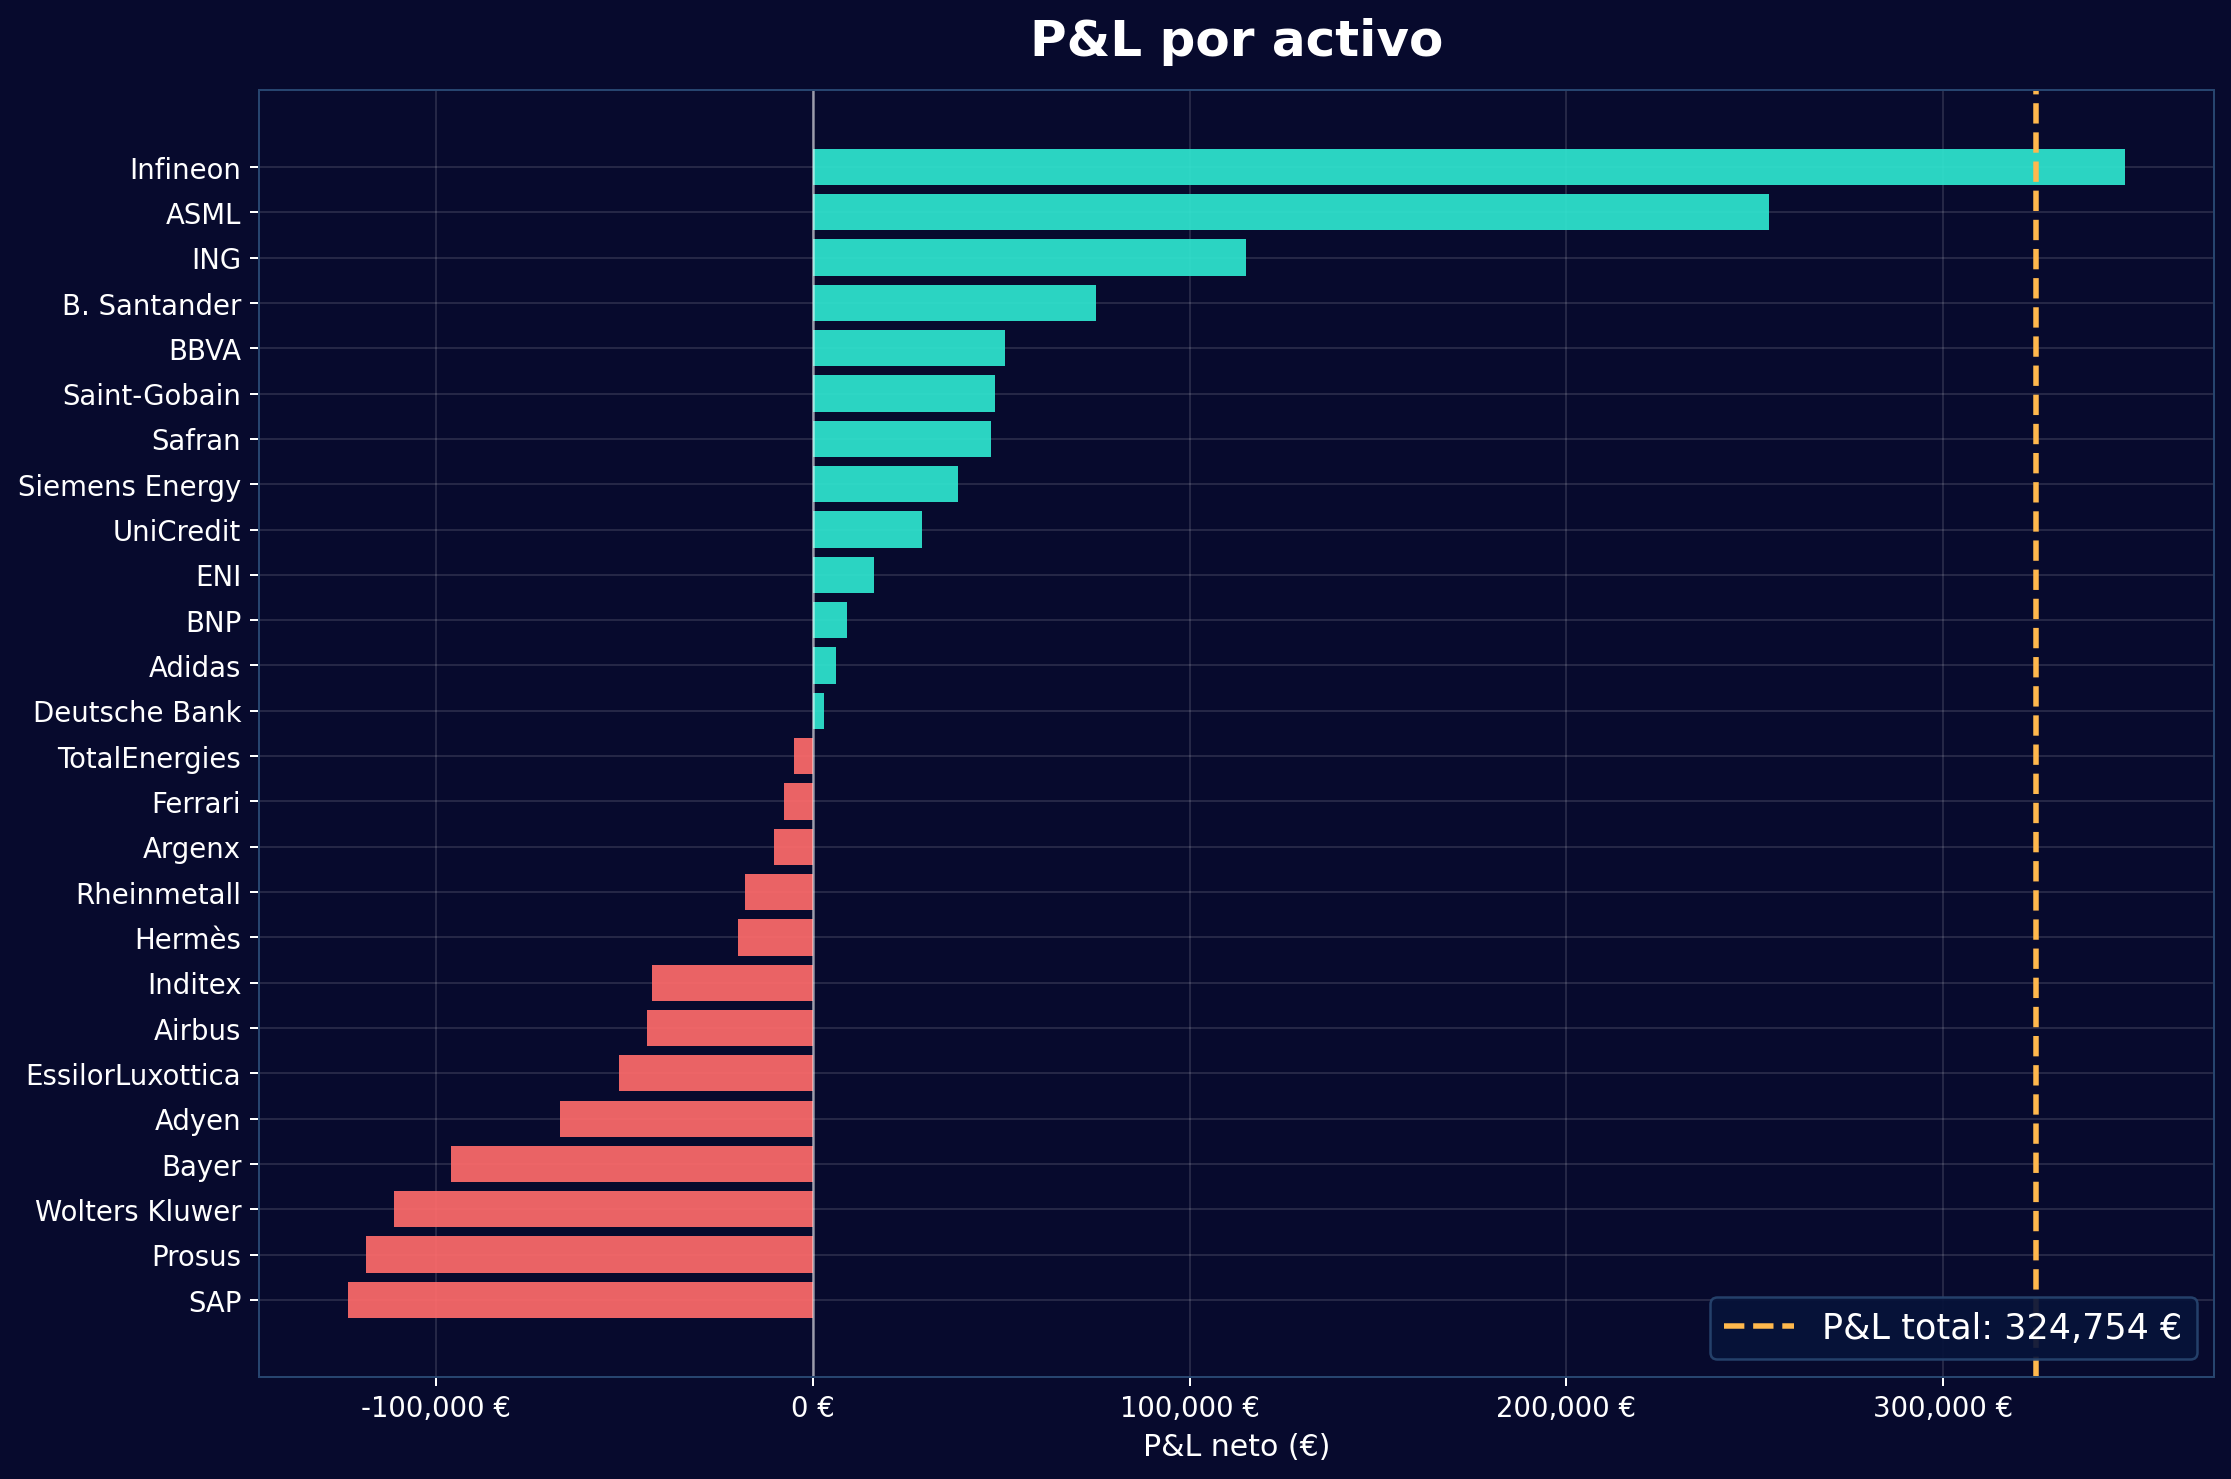

In [63]:
tabla_pnl, fig, ax = pnl_por_activo(
    archivo=path,
    fecha_fin=fecha_fin,
    formato="memoria"
)
tabla_pnl, fig, ax = pnl_por_activo(
    archivo=path,
    fecha_fin=fecha_fin,
    formato="presentacion"
)

# Análisis del modelo

In [64]:
tabla_aciertos = tabla_aciertos_modelo(
    archivo=path,
    universo_tickers=universo_tickers,
    semanal=semanal,
    fecha_fin=fecha_fin,
)

tabla_aciertos

c:\Users\Deportivo Estadio\Desktop\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\Trabajo_gestion_cuantitativa\Monitoring\auxfun.py:62: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  fecha_fin = pd.Timestamp.today().normalize() if fecha_fin is None else pd.to_datetime(fecha_fin, dayfirst=True).normalize()


,Semana,Top 15,Baten BMK,Alpha cartera
0,Semana 1,3,5,-0.012212
1,Semana 2,6,7,-0.004678
2,Semana 3,2,10,0.010123
3,Semana 4,8,9,-0.009474
4,Semana 5,7,12,-0.020063
5,Semana 6,5,6,0.024619
6,Semana 7,9,15,0.024617
7,Semana 8,3,3,-0.023525
8,Semana 9,4,8,0.022601
